# Supplementary 1: Reward functions testing

PPO

----------------- Running RMSE Analysis for ppo_b100 -----------------
----------------- Model Used <stable_baselines3.ppo.ppo.PPO object at 0x00000228E6AF5940> -----------------
----------------- Running RMSE Analysis for ppo_c -----------------
----------------- Model Used <stable_baselines3.ppo.ppo.PPO object at 0x00000228FF3D9A60> -----------------
----------------- Running RMSE Analysis for ppo_c+n -----------------
----------------- Model Used <stable_baselines3.ppo.ppo.PPO object at 0x00000228E50678C0> -----------------
----------------- Running RMSE Analysis for ppo_c10+n-10 -----------------
----------------- Model Used <stable_baselines3.ppo.ppo.PPO object at 0x00000228FF3233B0> -----------------
----------------- Running RMSE Analysis for ppo_c10+n-10_b100 -----------------
----------------- Model Used <stable_baselines3.ppo.ppo.PPO object at 0x00000228FF2040E0> -----------------
----------------- Running RMSE Analysis for ppo_target3.5 -----------------
----------------- Mo

C:\Users\Reuel Group\AppData\Local\Temp\ipykernel_27232\1764548414.py:176: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=label_names)


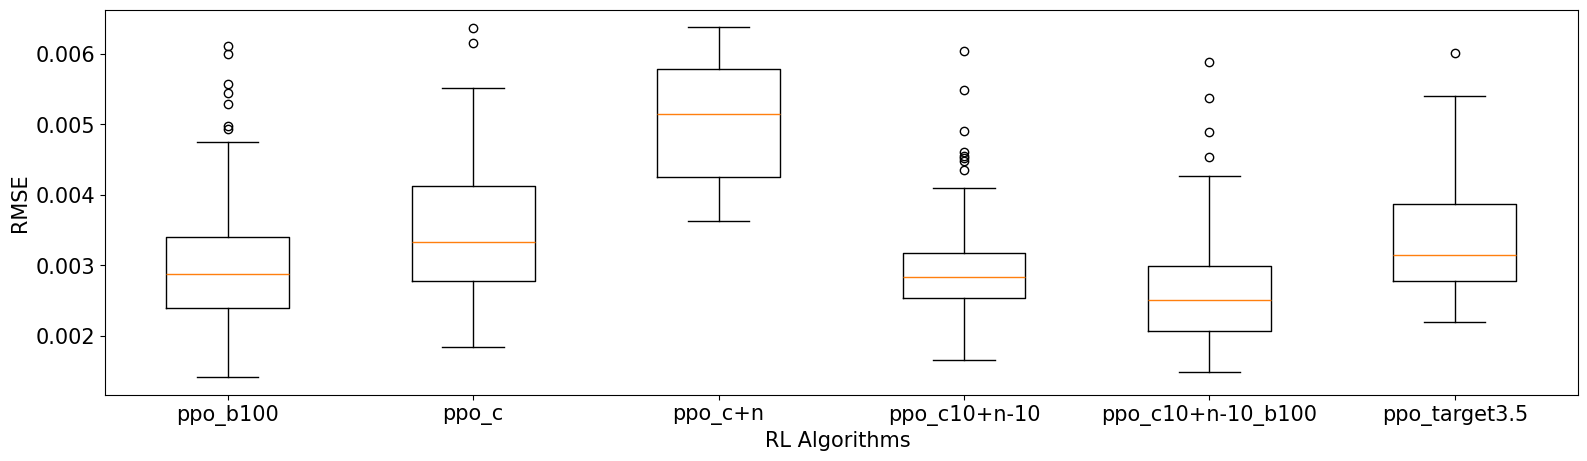

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math
import pandas as pd
import random 
import config
from scipy.interpolate import CubicSpline
import utils
import os
from stable_baselines3 import PPO,SAC,A2C,TD3, DDPG
import utils

experiments = os.listdir("experiments")
names = []

for ac in experiments:
    if 'ppo' in ac:
        names.append(ac)
figure_data = {}


for experiment_name in names:

    experiment_folder = os.path.join("experiments",experiment_name)
    best_model_folder = os.path.join(experiment_folder, "model" )
    best_model_path = os.path.join(best_model_folder, "best_model.zip")

    if 'ppo' in experiment_name:
        loaded_model = PPO.load(best_model_path)
    elif 'sac' in experiment_name:
        loaded_model = SAC.load(best_model_path)
    elif 'a2c' in experiment_name:
        loaded_model = A2C.load(best_model_path)
    elif 'td3' in experiment_name:
        loaded_model = TD3.load(best_model_path)
    elif 'ddpg' in experiment_name:
        loaded_model = DDPG.load(best_model_path)
    
    print(f"----------------- Running RMSE Analysis for {experiment_name} -----------------")
    print(f"----------------- Model Used {loaded_model} -----------------")


    figure_data[experiment_name] = []
    num_experiments = 100

    for experiment in range(1, num_experiments+1):
        # Initial conditions
        X0 = config.X0  # CDW g/L 
        S0 = config.S0 # mol/L
        E0 = config.E0 # U/L 

        # Process conditions
        T = config.INIT_TEMPRATURE #'C 
        T_opt = config.OPTIMUM_TEMPERATURE #'C
        A = config.INIT_AGITATION # RPM

        # model parameters
        Ks = config.KS    # mol/L
        Yxs =  config.YXS  # CDW g/mol
        MuE_opt = config.MUE_OPT    # U/CDW g
        mu_max = config.MU_MAX   # /h
        del_t = config.DEL_T # hours ie. 36 seconds
        t_end = config.T_END
        total_sim_steps = int(t_end/del_t)
        tvec = [del_t + i * del_t for i in range(total_sim_steps)]
        ns = len(tvec)
        kl = config.KL # mol/L
        cell_death_timer = config.CELL_DEATH_TIMER
        cell_death_time = config.CELL_DEATH_TIME

        # Substrate addition calculations
        tank_capacity = config.TANK_CAPACITY # L
        substrate_in_tank_liters = config.SUBSTRATE_IN_TANK_LITERS # L
        max_substrate_limit_liters = config.MAX_SUBSTRATE_LIMIT_LITERS # L
        substrate_transfer_amount_liters = config.SUBSTRATE_TRANSFER_AMOUNT_LITERS # L 
        media_transfer_gap =  config.MEDIA_TRANSFER_GAP # Hours this is after 10 steps ie. 6 minutes
        media_transfer_step = int(media_transfer_gap/del_t)
        substrate_concentration = S0
        sub_in_tank_moles = S0 * substrate_in_tank_liters # mol

        # external media tank configurations
        ext_tank_substrate_conc = config.EXT_TANK_SUBSTRATE_CONC # mol/L
        substrate_transfer_moles = substrate_transfer_amount_liters * ext_tank_substrate_conc # mol 

        # X S E delE delX, muE
        D = np.zeros((ns+1, 6))
        D[0][0] = X0
        D[0][1] = substrate_concentration
        D[0][2] = E0
        for i in range(ns):
            X = D[i][0]
            S = D[i][1]
            E = D[i][2]

            MuX = utils.cell_growth_rate(S)
            # new cells that are generated
            dXdt = utils.cells_produced(X, MuX)

            # SUbstrate consumption
            dSdt = utils.substrate_consumed(dXdt)

            # Find change in cells 
            delX = dXdt * del_t
            # Update cells
            D[i+1][0] = X + delX
            
            # Find change in substrate
            delS = dSdt * del_t

            # # Update substrate
            if substrate_in_tank_liters < max_substrate_limit_liters:
                if i%(media_transfer_step) == 0 and i != 0:
                    if loaded_model.observation_space.shape[0] == 2:
                        model_input = np.array([i, E])
                    elif loaded_model.observation_space.shape[0] == 3:
                        model_input = np.array([i, E, X])
                    action = loaded_model.predict(model_input, deterministic=False)
                    substrate_action = action[0][0]
                    if True:
                        # get substrate concentraion for current timestep
                        substrate_concentration = S
                        sub_in_tank_moles = substrate_concentration * substrate_in_tank_liters
                        # Add substrate and calculate new concentraion
                        substrate_in_tank_liters = substrate_in_tank_liters + substrate_action # Liters of media
                        sub_in_tank_moles = sub_in_tank_moles + ext_tank_substrate_conc * substrate_action  # grams
                        substrate_concentration = sub_in_tank_moles/substrate_in_tank_liters # substrate grams/liter
                        S = substrate_concentration

            # Check if substrate is less than or close to 0
            if S + delS < 0.000001:
                D[i+1][1] = 0
            else:
                D[i+1][1] = S + delS

            # Enzyme determination 
            sub_cell_ratio = (S/X) * 1e6

            weibull = utils.get_weibull_y_value(sub_cell_ratio, peak = config.OPT_SUB_CELL_RATIO*1e6)
            MuE = MuE_opt * weibull

            if dXdt == 0:
                MuE = 0

            # new enzyme from fresh cells
            delE = MuE * X * del_t
            
            # Update enzyme variable
            D[i+1][2] = E + delE

            # terminate if tank capacity is full and cells start dying
            if substrate_in_tank_liters >= max_substrate_limit_liters and dXdt == 0:
                break
            
        X = D[:,0][0:i]
        S = D[:,1][0:i]
        E = D[:,2][0:i]
        ratios = (S/X)
        rmse = utils.calculate_rmse( ratios, config.OPT_SUB_CELL_RATIO )  
        figure_data[experiment_name].append(rmse)


# Time points
time = list(range(1, 101))  # Time from 1 to 100
data = []
label_names = []

for key, values in figure_data.items():
    data.append(values)
    label_names.append(key)


# Combine lists into a single list of lists for the box plot

plt.figure(figsize=(19, 5))
# Create the box plot
plt.boxplot(data, labels=label_names)

# Customize the plot
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.ylabel('RMSE', fontsize=15)
plt.xlabel('RL Algorithms ', fontsize=15)

# Show the plot
plt.show()




# SAC All

----------------- Running RMSE Analysis for sac_b100 -----------------
----------------- Model Used <stable_baselines3.sac.sac.SAC object at 0x00000228FF37F050> -----------------
----------------- Running RMSE Analysis for sac_c -----------------
----------------- Model Used <stable_baselines3.sac.sac.SAC object at 0x00000228F8877FE0> -----------------
----------------- Running RMSE Analysis for sac_c+n -----------------
----------------- Model Used <stable_baselines3.sac.sac.SAC object at 0x00000228FE849160> -----------------
----------------- Running RMSE Analysis for sac_c10+n-10 -----------------
----------------- Model Used <stable_baselines3.sac.sac.SAC object at 0x00000228F8812BD0> -----------------
----------------- Running RMSE Analysis for sac_c10+n-10_b100 -----------------
----------------- Model Used <stable_baselines3.sac.sac.SAC object at 0x00000228FF75AC00> -----------------
----------------- Running RMSE Analysis for sac_rt_scr-0.0024444_mopt-0.14 -----------------
---

C:\Users\Reuel Group\AppData\Local\Temp\ipykernel_27232\3253083696.py:176: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=label_names)


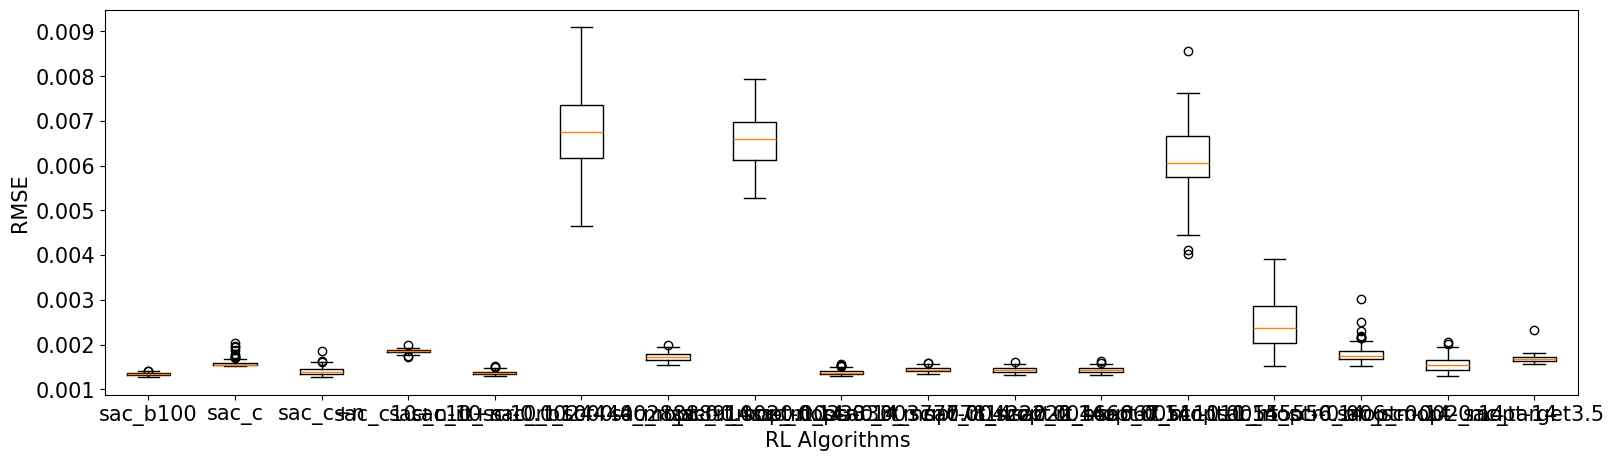

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import math
import pandas as pd
import random 
import config
from scipy.interpolate import CubicSpline
import utils
import os
from stable_baselines3 import PPO,SAC,A2C,TD3, DDPG
import utils

experiments = os.listdir("experiments")
names = []

for ac in experiments:
    if 'sac_2' not in ac and 'cb' not in ac and 'sac' in ac:
        names.append(ac)
figure_data = {}


for experiment_name in names:

    experiment_folder = os.path.join("experiments",experiment_name)
    best_model_folder = os.path.join(experiment_folder, "model" )
    best_model_path = os.path.join(best_model_folder, "best_model.zip")

    if 'ppo' in experiment_name:
        loaded_model = PPO.load(best_model_path)
    elif 'sac' in experiment_name:
        loaded_model = SAC.load(best_model_path)
    elif 'a2c' in experiment_name:
        loaded_model = A2C.load(best_model_path)
    elif 'td3' in experiment_name:
        loaded_model = TD3.load(best_model_path)
    elif 'ddpg' in experiment_name:
        loaded_model = DDPG.load(best_model_path)
    
    print(f"----------------- Running RMSE Analysis for {experiment_name} -----------------")
    print(f"----------------- Model Used {loaded_model} -----------------")


    figure_data[experiment_name] = []
    num_experiments = 100

    for experiment in range(1, num_experiments+1):
        # Initial conditions
        X0 = config.X0  # CDW g/L 
        S0 = config.S0 # mol/L
        E0 = config.E0 # U/L 

        # Process conditions
        T = config.INIT_TEMPRATURE #'C 
        T_opt = config.OPTIMUM_TEMPERATURE #'C
        A = config.INIT_AGITATION # RPM

        # model parameters
        Ks = config.KS    # mol/L
        Yxs =  config.YXS  # CDW g/mol
        MuE_opt = config.MUE_OPT    # U/CDW g
        mu_max = config.MU_MAX   # /h
        del_t = config.DEL_T # hours ie. 36 seconds
        t_end = config.T_END
        total_sim_steps = int(t_end/del_t)
        tvec = [del_t + i * del_t for i in range(total_sim_steps)]
        ns = len(tvec)
        kl = config.KL # mol/L
        cell_death_timer = config.CELL_DEATH_TIMER
        cell_death_time = config.CELL_DEATH_TIME

        # Substrate addition calculations
        tank_capacity = config.TANK_CAPACITY # L
        substrate_in_tank_liters = config.SUBSTRATE_IN_TANK_LITERS # L
        max_substrate_limit_liters = config.MAX_SUBSTRATE_LIMIT_LITERS # L
        substrate_transfer_amount_liters = config.SUBSTRATE_TRANSFER_AMOUNT_LITERS # L 
        media_transfer_gap =  config.MEDIA_TRANSFER_GAP # Hours this is after 10 steps ie. 6 minutes
        media_transfer_step = int(media_transfer_gap/del_t)
        substrate_concentration = S0
        sub_in_tank_moles = S0 * substrate_in_tank_liters # mol

        # external media tank configurations
        ext_tank_substrate_conc = config.EXT_TANK_SUBSTRATE_CONC # mol/L
        substrate_transfer_moles = substrate_transfer_amount_liters * ext_tank_substrate_conc # mol 

        # X S E delE delX, muE
        D = np.zeros((ns+1, 6))
        D[0][0] = X0
        D[0][1] = substrate_concentration
        D[0][2] = E0
        for i in range(ns):
            X = D[i][0]
            S = D[i][1]
            E = D[i][2]

            MuX = utils.cell_growth_rate(S)
            # new cells that are generated
            dXdt = utils.cells_produced(X, MuX)

            # SUbstrate consumption
            dSdt = utils.substrate_consumed(dXdt)

            # Find change in cells 
            delX = dXdt * del_t
            # Update cells
            D[i+1][0] = X + delX
            
            # Find change in substrate
            delS = dSdt * del_t

            # # Update substrate
            if substrate_in_tank_liters < max_substrate_limit_liters:
                if i%(media_transfer_step) == 0 and i != 0:
                    if loaded_model.observation_space.shape[0] == 2:
                        model_input = np.array([i, E])
                    elif loaded_model.observation_space.shape[0] == 3:
                        model_input = np.array([i, E, X])
                    action = loaded_model.predict(model_input, deterministic=False)
                    substrate_action = action[0][0]
                    if True:
                        # get substrate concentraion for current timestep
                        substrate_concentration = S
                        sub_in_tank_moles = substrate_concentration * substrate_in_tank_liters
                        # Add substrate and calculate new concentraion
                        substrate_in_tank_liters = substrate_in_tank_liters + substrate_action # Liters of media
                        sub_in_tank_moles = sub_in_tank_moles + ext_tank_substrate_conc * substrate_action  # grams
                        substrate_concentration = sub_in_tank_moles/substrate_in_tank_liters # substrate grams/liter
                        S = substrate_concentration

            # Check if substrate is less than or close to 0
            if S + delS < 0.000001:
                D[i+1][1] = 0
            else:
                D[i+1][1] = S + delS

            # Enzyme determination 
            sub_cell_ratio = (S/X) * 1e6

            weibull = utils.get_weibull_y_value(sub_cell_ratio, peak = config.OPT_SUB_CELL_RATIO*1e6)
            MuE = MuE_opt * weibull

            if dXdt == 0:
                MuE = 0

            # new enzyme from fresh cells
            delE = MuE * X * del_t
            
            # Update enzyme variable
            D[i+1][2] = E + delE

            # terminate if tank capacity is full and cells start dying
            if substrate_in_tank_liters >= max_substrate_limit_liters and dXdt == 0:
                break
            
        X = D[:,0][0:i]
        S = D[:,1][0:i]
        E = D[:,2][0:i]
        ratios = (S/X)
        rmse = utils.calculate_rmse( ratios, config.OPT_SUB_CELL_RATIO )  
        figure_data[experiment_name].append(rmse)


# Time points
time = list(range(1, 101))  # Time from 1 to 100
data = []
label_names = []

for key, values in figure_data.items():
    data.append(values)
    label_names.append(key)


# Combine lists into a single list of lists for the box plot

plt.figure(figsize=(19, 5))
# Create the box plot
plt.boxplot(data, labels=label_names)

# Customize the plot
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.ylabel('RMSE', fontsize=15)
plt.xlabel('RL Algorithms ', fontsize=15)

# Show the plot
plt.show()




----------------- Running RMSE Analysis for ppo_c10+n-10_b100 -----------------
----------------- Model Used <stable_baselines3.ppo.ppo.PPO object at 0x000002571ED57680> -----------------
----------------- Running RMSE Analysis for sac_c10+n-10_b100 -----------------
----------------- Model Used <stable_baselines3.sac.sac.SAC object at 0x000002571F15CFB0> -----------------


C:\Users\Reuel Group\AppData\Local\Temp\ipykernel_33360\2931507837.py:177: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=label_names)


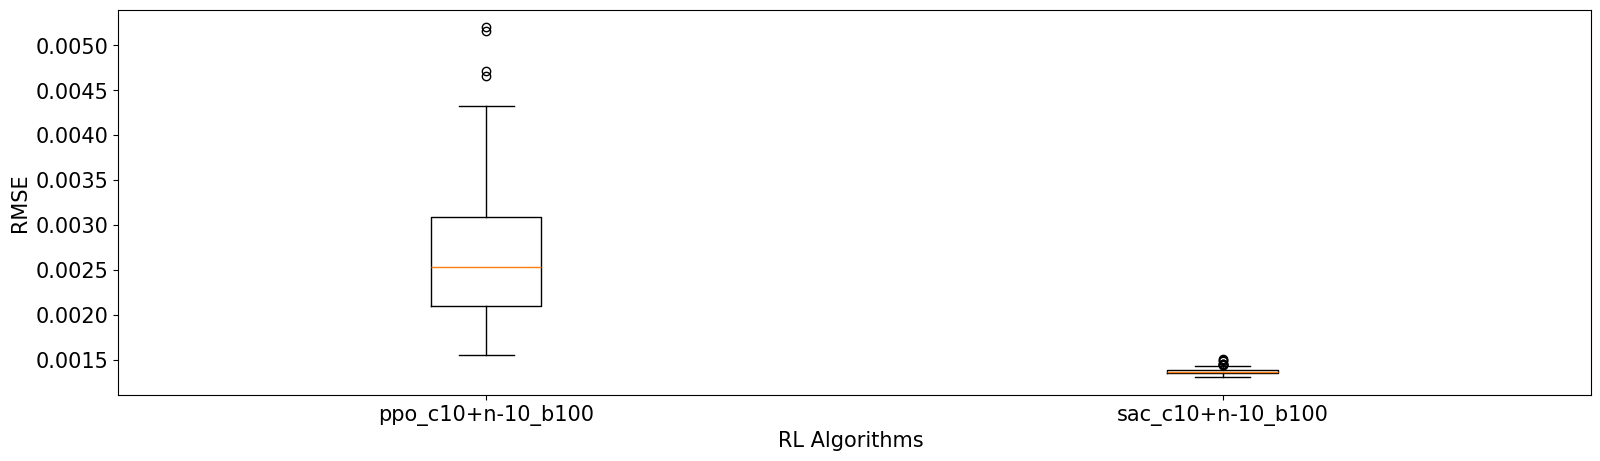

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import math
import pandas as pd
import random 
import config
from scipy.interpolate import CubicSpline
import utils
import os
from stable_baselines3 import PPO,SAC,A2C,TD3, DDPG
import utils

# experiments = os.listdir("experiments")
# names = []

# for ac in experiments:
#     if 'ppo' in ac:
#         names.append(ac)
figure_data = {}

names = ['ppo_c10+n-10_b100', 'sac_c10+n-10_b100']

for experiment_name in names:

    experiment_folder = os.path.join("experiments",experiment_name)
    best_model_folder = os.path.join(experiment_folder, "model" )
    best_model_path = os.path.join(best_model_folder, "best_model.zip")

    if 'ppo' in experiment_name:
        loaded_model = PPO.load(best_model_path)
    elif 'sac' in experiment_name:
        loaded_model = SAC.load(best_model_path)
    elif 'a2c' in experiment_name:
        loaded_model = A2C.load(best_model_path)
    elif 'td3' in experiment_name:
        loaded_model = TD3.load(best_model_path)
    elif 'ddpg' in experiment_name:
        loaded_model = DDPG.load(best_model_path)
    
    print(f"----------------- Running RMSE Analysis for {experiment_name} -----------------")
    print(f"----------------- Model Used {loaded_model} -----------------")


    figure_data[experiment_name] = []
    num_experiments = 100

    for experiment in range(1, num_experiments+1):
        # Initial conditions
        X0 = config.X0  # CDW g/L 
        S0 = config.S0 # mol/L
        E0 = config.E0 # U/L 

        # Process conditions
        T = config.INIT_TEMPRATURE #'C 
        T_opt = config.OPTIMUM_TEMPERATURE #'C
        A = config.INIT_AGITATION # RPM

        # model parameters
        Ks = config.KS    # mol/L
        Yxs =  config.YXS  # CDW g/mol
        MuE_opt = config.MUE_OPT    # U/CDW g
        mu_max = config.MU_MAX   # /h
        del_t = config.DEL_T # hours ie. 36 seconds
        t_end = config.T_END
        total_sim_steps = int(t_end/del_t)
        tvec = [del_t + i * del_t for i in range(total_sim_steps)]
        ns = len(tvec)
        kl = config.KL # mol/L
        cell_death_timer = config.CELL_DEATH_TIMER
        cell_death_time = config.CELL_DEATH_TIME

        # Substrate addition calculations
        tank_capacity = config.TANK_CAPACITY # L
        substrate_in_tank_liters = config.SUBSTRATE_IN_TANK_LITERS # L
        max_substrate_limit_liters = config.MAX_SUBSTRATE_LIMIT_LITERS # L
        substrate_transfer_amount_liters = config.SUBSTRATE_TRANSFER_AMOUNT_LITERS # L 
        media_transfer_gap =  config.MEDIA_TRANSFER_GAP # Hours this is after 10 steps ie. 6 minutes
        media_transfer_step = int(media_transfer_gap/del_t)
        substrate_concentration = S0
        sub_in_tank_moles = S0 * substrate_in_tank_liters # mol

        # external media tank configurations
        ext_tank_substrate_conc = config.EXT_TANK_SUBSTRATE_CONC # mol/L
        substrate_transfer_moles = substrate_transfer_amount_liters * ext_tank_substrate_conc # mol 

        # X S E delE delX, muE
        D = np.zeros((ns+1, 6))
        D[0][0] = X0
        D[0][1] = substrate_concentration
        D[0][2] = E0
        for i in range(ns):
            X = D[i][0]
            S = D[i][1]
            E = D[i][2]

            MuX = utils.cell_growth_rate(S)
            # new cells that are generated
            dXdt = utils.cells_produced(X, MuX)

            # SUbstrate consumption
            dSdt = utils.substrate_consumed(dXdt)

            # Find change in cells 
            delX = dXdt * del_t
            # Update cells
            D[i+1][0] = X + delX
            
            # Find change in substrate
            delS = dSdt * del_t

            # # Update substrate
            if substrate_in_tank_liters < max_substrate_limit_liters:
                if i%(media_transfer_step) == 0 and i != 0:
                    if loaded_model.observation_space.shape[0] == 2:
                        model_input = np.array([i, E])
                    elif loaded_model.observation_space.shape[0] == 3:
                        model_input = np.array([i, E, X])
                    action = loaded_model.predict(model_input, deterministic=False)
                    substrate_action = action[0][0]
                    if True:
                        # get substrate concentraion for current timestep
                        substrate_concentration = S
                        sub_in_tank_moles = substrate_concentration * substrate_in_tank_liters
                        # Add substrate and calculate new concentraion
                        substrate_in_tank_liters = substrate_in_tank_liters + substrate_action # Liters of media
                        sub_in_tank_moles = sub_in_tank_moles + ext_tank_substrate_conc * substrate_action  # grams
                        substrate_concentration = sub_in_tank_moles/substrate_in_tank_liters # substrate grams/liter
                        S = substrate_concentration

            # Check if substrate is less than or close to 0
            if S + delS < 0.000001:
                D[i+1][1] = 0
            else:
                D[i+1][1] = S + delS

            # Enzyme determination 
            sub_cell_ratio = (S/X) * 1e6

            weibull = utils.get_weibull_y_value(sub_cell_ratio, peak = config.OPT_SUB_CELL_RATIO*1e6)
            MuE = MuE_opt * weibull

            if dXdt == 0:
                MuE = 0

            # new enzyme from fresh cells
            delE = MuE * X * del_t
            
            # Update enzyme variable
            D[i+1][2] = E + delE

            # terminate if tank capacity is full and cells start dying
            if substrate_in_tank_liters >= max_substrate_limit_liters and dXdt == 0:
                break
            
        X = D[:,0][0:i]
        S = D[:,1][0:i]
        E = D[:,2][0:i]
        ratios = (S/X)
        rmse = utils.calculate_rmse( ratios, config.OPT_SUB_CELL_RATIO )  
        figure_data[experiment_name].append(rmse)


# Time points
time = list(range(1, 101))  # Time from 1 to 100
data = []
label_names = []

for key, values in figure_data.items():
    data.append(values)
    label_names.append(key)


# Combine lists into a single list of lists for the box plot

plt.figure(figsize=(19, 5))
# Create the box plot
plt.boxplot(data, labels=label_names)

# Customize the plot
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.ylabel('RMSE', fontsize=15)
plt.xlabel('RL Algorithms ', fontsize=15)

# Show the plot
plt.show()




# SAC Boxplot for reward function

----------------- Running RMSE Analysis for sac_2 -----------------
----------------- Model Used <stable_baselines3.sac.sac.SAC object at 0x000002065E6E5C70> -----------------
----------------- Running RMSE Analysis for sac_b100 -----------------
----------------- Model Used <stable_baselines3.sac.sac.SAC object at 0x0000020667B10E90> -----------------
----------------- Running RMSE Analysis for sac_c -----------------
----------------- Model Used <stable_baselines3.sac.sac.SAC object at 0x000002065E6AF650> -----------------
----------------- Running RMSE Analysis for sac_c+n -----------------
----------------- Model Used <stable_baselines3.sac.sac.SAC object at 0x0000020645CD57C0> -----------------
----------------- Running RMSE Analysis for sac_c10+n-10 -----------------
----------------- Model Used <stable_baselines3.sac.sac.SAC object at 0x000002065E6AF650> -----------------
----------------- Running RMSE Analysis for sac_c10+n-10_b100 -----------------
----------------- Model Used

C:\Users\Reuel Group\AppData\Local\Temp\ipykernel_22172\925859675.py:175: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=label_names)


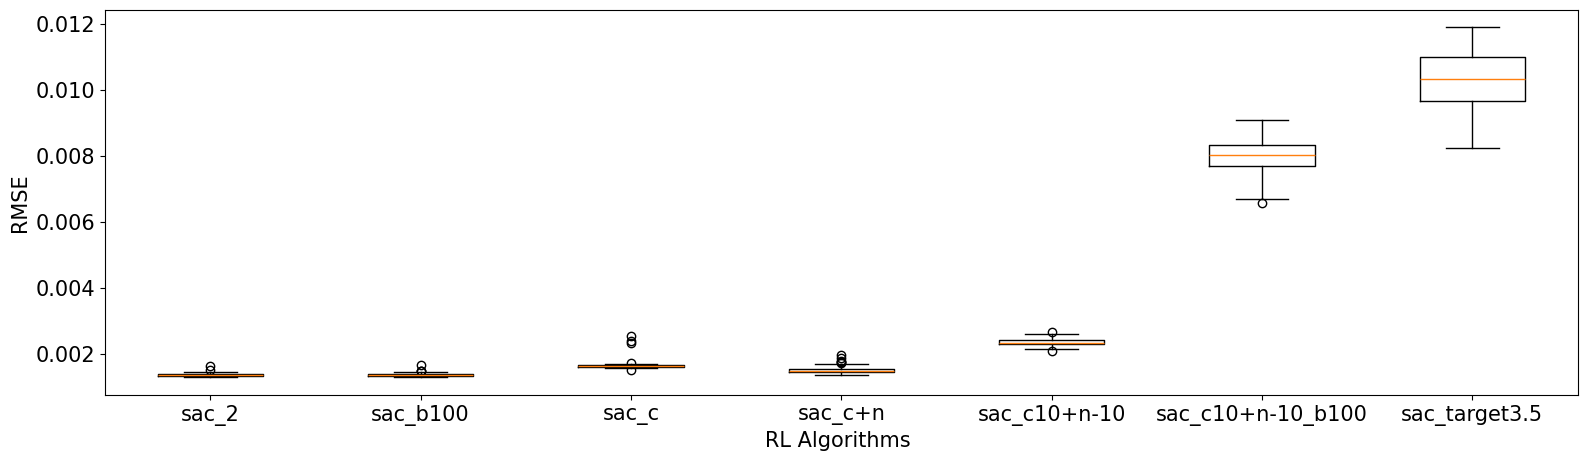

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import math
import pandas as pd
import random 
import config
from scipy.interpolate import CubicSpline
import utils
import os
from stable_baselines3 import PPO,SAC,A2C,TD3, DDPG
import utils

experiments = os.listdir("experiments")
names = []

for ac in experiments:
    if 'sac' in ac and 'eval' not in ac and 'rt' not in ac:
        names.append(ac)
figure_data = {}

for experiment_name in names:

    experiment_folder = os.path.join("experiments",experiment_name)
    best_model_folder = os.path.join(experiment_folder, "model" )
    best_model_path = os.path.join(best_model_folder, "best_model.zip")

    if 'ppo' in experiment_name:
        loaded_model = PPO.load(best_model_path)
    elif 'sac' in experiment_name:
        loaded_model = SAC.load(best_model_path)
    elif 'a2c' in experiment_name:
        loaded_model = A2C.load(best_model_path)
    elif 'td3' in experiment_name:
        loaded_model = TD3.load(best_model_path)
    elif 'ddpg' in experiment_name:
        loaded_model = DDPG.load(best_model_path)
    
    print(f"----------------- Running RMSE Analysis for {experiment_name} -----------------")
    print(f"----------------- Model Used {loaded_model} -----------------")


    figure_data[experiment_name] = []
    num_experiments = 100

    for experiment in range(1, num_experiments+1):
        # Initial conditions
        X0 = config.X0  # CDW g/L 
        S0 = config.S0 # mol/L
        E0 = config.E0 # U/L 

        # Process conditions
        T = config.INIT_TEMPRATURE #'C 
        T_opt = config.OPTIMUM_TEMPERATURE #'C
        A = config.INIT_AGITATION # RPM

        # model parameters
        Ks = config.KS    # mol/L
        Yxs =  config.YXS  # CDW g/mol
        MuE_opt = config.MUE_OPT    # U/CDW g
        mu_max = config.MU_MAX   # /h
        del_t = config.DEL_T # hours ie. 36 seconds
        t_end = config.T_END
        total_sim_steps = int(t_end/del_t)
        tvec = [del_t + i * del_t for i in range(total_sim_steps)]
        ns = len(tvec)
        kl = config.KL # mol/L
        cell_death_timer = config.CELL_DEATH_TIMER
        cell_death_time = config.CELL_DEATH_TIME

        # Substrate addition calculations
        tank_capacity = config.TANK_CAPACITY # L
        substrate_in_tank_liters = config.SUBSTRATE_IN_TANK_LITERS # L
        max_substrate_limit_liters = config.MAX_SUBSTRATE_LIMIT_LITERS # L
        substrate_transfer_amount_liters = config.SUBSTRATE_TRANSFER_AMOUNT_LITERS # L 
        media_transfer_gap =  config.MEDIA_TRANSFER_GAP # Hours this is after 10 steps ie. 6 minutes
        media_transfer_step = int(media_transfer_gap/del_t)
        substrate_concentration = S0
        sub_in_tank_moles = S0 * substrate_in_tank_liters # mol

        # external media tank configurations
        ext_tank_substrate_conc = config.EXT_TANK_SUBSTRATE_CONC # mol/L
        substrate_transfer_moles = substrate_transfer_amount_liters * ext_tank_substrate_conc # mol 

        # X S E delE delX, muE
        D = np.zeros((ns+1, 6))
        D[0][0] = X0
        D[0][1] = substrate_concentration
        D[0][2] = E0
        for i in range(ns):
            X = D[i][0]
            S = D[i][1]
            E = D[i][2]

            MuX = utils.cell_growth_rate(S)
            # new cells that are generated
            dXdt = utils.cells_produced(X, MuX)

            # SUbstrate consumption
            dSdt = utils.substrate_consumed(dXdt)

            # Find change in cells 
            delX = dXdt * del_t
            # Update cells
            D[i+1][0] = X + delX
            
            # Find change in substrate
            delS = dSdt * del_t

            # # Update substrate
            if substrate_in_tank_liters < max_substrate_limit_liters:
                if i%(media_transfer_step) == 0 and i != 0:
                    if loaded_model.observation_space.shape[0] == 2:
                        model_input = np.array([i, E])
                    elif loaded_model.observation_space.shape[0] == 3:
                        model_input = np.array([i, E, X])
                    action = loaded_model.predict(model_input, deterministic=False)
                    substrate_action = action[0][0]
                    if True:
                        # get substrate concentraion for current timestep
                        substrate_concentration = S
                        sub_in_tank_moles = substrate_concentration * substrate_in_tank_liters
                        # Add substrate and calculate new concentraion
                        substrate_in_tank_liters = substrate_in_tank_liters + substrate_action # Liters of media
                        sub_in_tank_moles = sub_in_tank_moles + ext_tank_substrate_conc * substrate_action  # grams
                        substrate_concentration = sub_in_tank_moles/substrate_in_tank_liters # substrate grams/liter
                        S = substrate_concentration

            # Check if substrate is less than or close to 0
            if S + delS < 0.000001:
                D[i+1][1] = 0
            else:
                D[i+1][1] = S + delS

            # Enzyme determination 
            sub_cell_ratio = (S/X) * 1e6

            weibull = utils.get_weibull_y_value(sub_cell_ratio, peak = config.OPT_SUB_CELL_RATIO*1e6)
            MuE = MuE_opt * weibull

            if dXdt == 0:
                MuE = 0

            # new enzyme from fresh cells
            delE = MuE * X * del_t
            
            # Update enzyme variable
            D[i+1][2] = E + delE

            # terminate if tank capacity is full and cells start dying
            if substrate_in_tank_liters >= max_substrate_limit_liters and dXdt == 0:
                break
            
        X = D[:,0][0:i]
        S = D[:,1][0:i]
        E = D[:,2][0:i]
        ratios = (S/X)
        rmse = utils.calculate_rmse( ratios, config.OPT_SUB_CELL_RATIO )  
        figure_data[experiment_name].append(rmse)


# Time points
time = list(range(1, 101))  # Time from 1 to 100
data = []
label_names = []

for key, values in figure_data.items():
    data.append(values)
    label_names.append(key)


# Combine lists into a single list of lists for the box plot

plt.figure(figsize=(19, 5))
# Create the box plot
plt.boxplot(data, labels=label_names)

# Customize the plot
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.ylabel('RMSE', fontsize=15)
plt.xlabel('RL Algorithms ', fontsize=15)

# Show the plot
plt.show()


# Supplimentary 2: Convergence for retraining on new cell type data

dict_values([4477, 3542, 3899])


Text(0, 0.5, 'Number of Episodes for retraining')

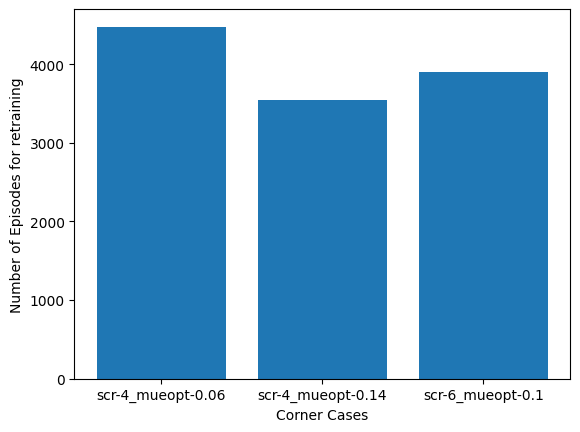

In [2]:
import matplotlib.pyplot as plt

corner_cases = {
    'scr-4_mueopt-0.06' : 4477,
    'scr-4_mueopt-0.14' : 3542,
    'scr-6_mueopt-0.1' : 3899,

}

X = corner_cases.keys()
Y = corner_cases.values()

print(Y)
plt.bar(X, Y)
plt.xlabel('Corner Cases')
plt.ylabel("Number of Episodes for retraining")


# Supplementary 3: Training vs Retraining

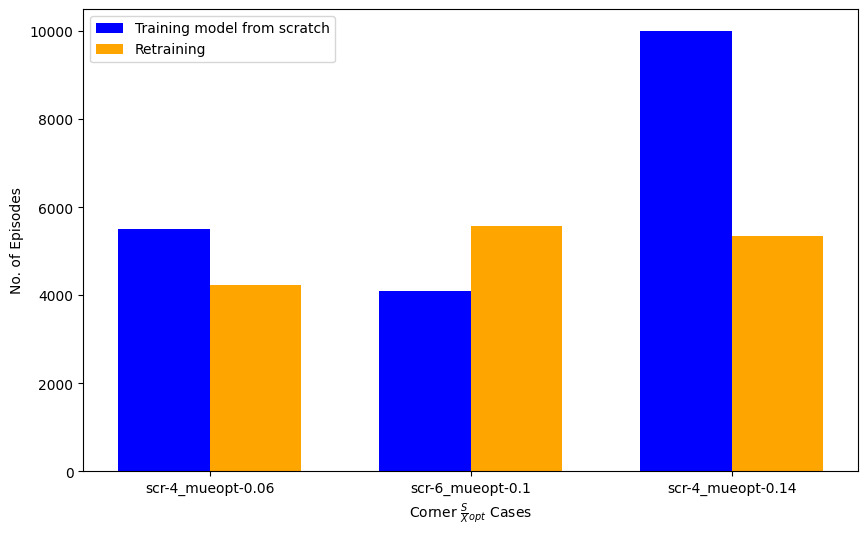

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Sample data
categories = ['scr-4_mueopt-0.06', 'scr-6_mueopt-0.1', 'scr-4_mueopt-0.14']
values1 = [5500, 4100, 10000]  # First dataset
values2 = [4245, 5578, 5349]   # Second dataset

# Set positions for bars
x = np.arange(len(categories))  # [0, 1, 2]
width = 0.35  # Width of bars

# Create the plot
fig, ax = plt.subplots(figsize=(10, 6))  # Increased size for better readability

# Plot bars
bars1 = ax.bar(x - width/2, values1, width, label='Training model from scratch', color='blue')
bars2 = ax.bar(x + width/2, values2, width, label='Retraining', color='orange')

# Labels and title
ax.set_xlabel(r"Corner $\frac{S}{X}_{opt}$ Cases")
ax.set_ylabel("No. of Episodes" )
ax.set_xticks(x)
ax.set_xticklabels(categories)  # Rotate for better readability
ax.legend()

# Show plot
plt.show()


# Supplementary 4: Temperature

([<matplotlib.axis.XTick at 0x22912cae090>,
 [Text(20, 0, '20'),
  Text(25, 0, '25'),
  Text(30, 0, '30'),
  Text(35, 0, '35'),
  Text(40, 0, '40')])

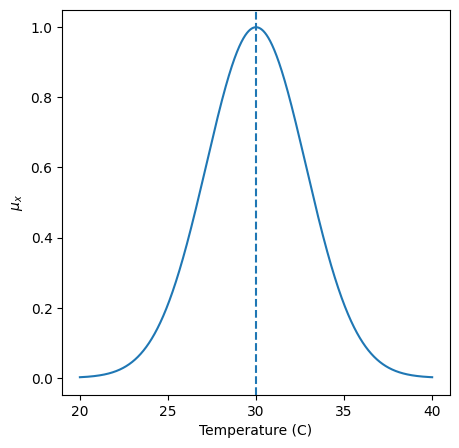

In [5]:
import numpy as np
import config
import numpy as np
import matplotlib.pyplot as plt
import os


temperatures = np.linspace(20, 40, 10000)
mux = []

for i in temperatures:
    x = np.exp(-((i - 30) ** 2) / (4 ** 2))
    
    mux.append(x)
# Set global font to Times New Roman
plt.rcParams["font.family"] = "DejaVu Sans"
plt.figure(figsize=(5,5))
plt.plot(temperatures, mux)
plt.xlabel("Temperature (C)", fontsize=10)
plt.ylabel(r"$\mu_x$",fontsize=10)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.axvline(x=30, linestyle='--')
figure_path = os.path.join('figures', 'supplementary', 'figure6a.svg')
plt.savefig(figure_path, format="svg", bbox_inches="tight", dpi=300)
plt.xticks(np.arange(20, 45, 5), fontsize=10)  # Adjust tick positions and spacing





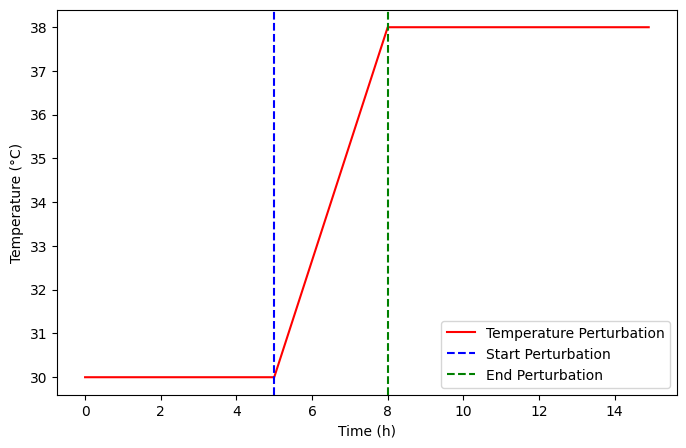

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline

# Define simulation parameters
start_hour = 5  # Time when temperature starts changing
end_hour = 8    # Time when temperature reaches the target
T_initial = 30   # Initial temperature
T_opt = 38       # Target temperature
del_t = 0.1      # Time step size

# Generate time steps
tvec = np.arange(0, 15, del_t)  # Simulating for 30 hours
temp_start_idx = int(start_hour / del_t)
temp_end_idx = int(end_hour / del_t)

# Create cubic spline for gradual temperature change
temp_spline = CubicSpline([temp_start_idx, temp_end_idx], [T_initial, T_opt])

# Apply the spline to temperature changes
temperature_profile = np.full_like(tvec, T_initial)  # Default to initial temp
temperature_profile[temp_start_idx:temp_end_idx] = temp_spline(np.arange(temp_start_idx, temp_end_idx))
temperature_profile[temp_end_idx:] = T_opt  # Maintain target temp after end_hour

# Plot the temperature perturbation curve
plt.figure(figsize=(8, 5))
plt.plot(tvec, temperature_profile, label="Temperature Perturbation", color='r')
plt.axvline(x=start_hour, linestyle="--", color='b', label="Start Perturbation")
plt.axvline(x=end_hour, linestyle="--", color='g', label="End Perturbation")
plt.xlabel("Time (h)")
plt.ylabel("Temperature (°C)")
plt.legend()
figure_path = os.path.join('figures', 'supplementary', 'figure6b.svg')
plt.savefig(figure_path, format="svg", bbox_inches="tight", dpi=300)
plt.show()


# Unkown optimal ratio

<Figure size 700x500 with 0 Axes>

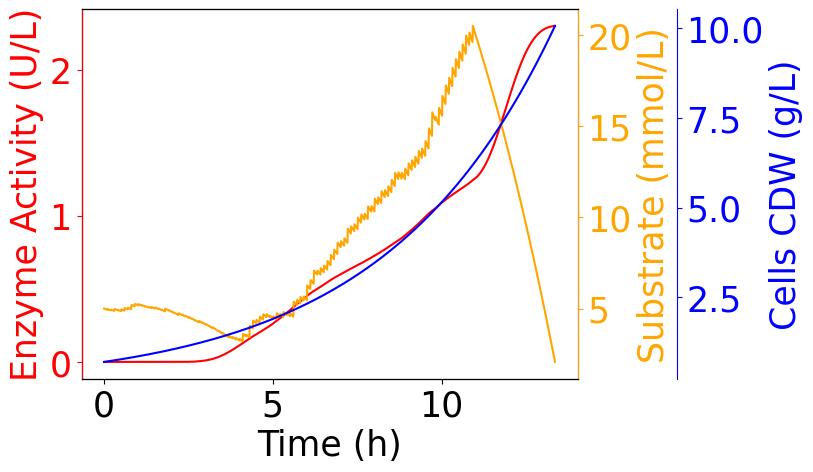

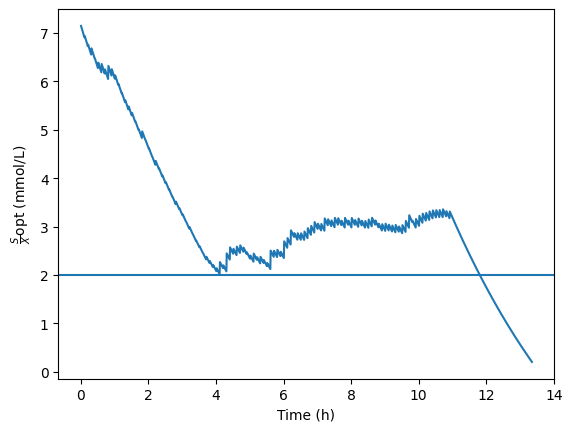

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import math
import pandas as pd
import random 
import config
from scipy.interpolate import CubicSpline
import utils
import os
from stable_baselines3 import PPO, SAC
import utils


best_model_path = os.path.join('experiments','sac_2', 'model', 'best_model.zip')
model_name = "SAC"

# Initiate the model dynamically based on config.MODEL
if model_name == "PPO":
    loaded_model = PPO.load(best_model_path)
elif model_name == "SAC":
    loaded_model = SAC.load(best_model_path)
else:
    raise ValueError(f"Unknown model name: {model_name}")


# Initial conditions
X0 = config.X0  # CDW g/L 
S0 = config.S0 # mol/L
E0 = config.E0 # U/L 

# Process conditions
T = config.INIT_TEMPRATURE #'C 
T_opt = config.OPTIMUM_TEMPERATURE #'C
A = config.INIT_AGITATION # RPM

# model parameters
Ks = config.KS    # mol/L
Yxs =  config.YXS  # CDW g/mol
MuE_opt = config.MUE_OPT    # U/CDW g
mu_max = config.MU_MAX   # /h
del_t = config.DEL_T # hours ie. 36 seconds
t_end = config.T_END
total_sim_steps = int(t_end/del_t)
tvec = [del_t + i * del_t for i in range(total_sim_steps)]
ns = len(tvec)
kl = config.KL # mol/L
cell_death_timer = config.CELL_DEATH_TIMER
cell_death_time = config.CELL_DEATH_TIME

# Substrate addition calculations
tank_capacity = config.TANK_CAPACITY # L
substrate_in_tank_liters = config.SUBSTRATE_IN_TANK_LITERS # L
max_substrate_limit_liters = config.MAX_SUBSTRATE_LIMIT_LITERS # L
substrate_transfer_amount_liters = config.SUBSTRATE_TRANSFER_AMOUNT_LITERS # L 
media_transfer_gap =  config.MEDIA_TRANSFER_GAP # Hours this is after 10 steps ie. 6 minutes
media_transfer_step = int(media_transfer_gap/del_t)
substrate_concentration = S0
sub_in_tank_moles = S0 * substrate_in_tank_liters # mol

# external media tank configurations
ext_tank_substrate_conc = config.EXT_TANK_SUBSTRATE_CONC # mol/L
substrate_transfer_moles = substrate_transfer_amount_liters * ext_tank_substrate_conc # mol 

# X S E delE delX, muE
D = np.zeros((ns+1, 6))
D[0][0] = X0
D[0][1] = substrate_concentration
D[0][2] = E0
for i in range(ns):
    X = D[i][0]
    S = D[i][1]
    E = D[i][2]

    MuX = utils.cell_growth_rate(S)
    # new cells that are generated
    dXdt = utils.cells_produced(X, MuX)

    # SUbstrate consumption
    dSdt = utils.substrate_consumed(dXdt)

    # Find change in cells 
    delX = dXdt * del_t
    # Update cells
    D[i+1][0] = X + delX
    
    # Find change in substrate
    delS = dSdt * del_t

    # # Update substrate
    if substrate_in_tank_liters < max_substrate_limit_liters:
        if i%(media_transfer_step) == 0 and i != 0:
            model_input = np.array([i, E, X])
            action = loaded_model.predict(model_input, deterministic=False)
            substrate_action = action[0][0]
            if True:
                # get substrate concentraion for current timestep
                substrate_concentration = S
                sub_in_tank_moles = substrate_concentration * substrate_in_tank_liters
                # Add substrate and calculate new concentraion
                substrate_in_tank_liters = substrate_in_tank_liters + substrate_action # Liters of media
                sub_in_tank_moles = sub_in_tank_moles + ext_tank_substrate_conc * substrate_action  # grams
                substrate_concentration = sub_in_tank_moles/substrate_in_tank_liters # substrate grams/liter
                S = substrate_concentration

    # Check if substrate is less than or close to 0
    if S + delS < 0.000001:
        D[i+1][1] = 0
    else:
        D[i+1][1] = S + delS

    # Enzyme determination 
    sub_cell_ratio = (S/X) * 1e6

    weibull = utils.get_weibull_y_value(sub_cell_ratio, peak=0.002 * 1e6)
    MuE = MuE_opt * weibull

    if dXdt == 0:
        MuE = 0

    # new enzyme from fresh cells
    delE = MuE * X * del_t
    
    # Update enzyme variable
    D[i+1][2] = E + delE

    # terminate if tank capacity is full and cells start dying
    if substrate_in_tank_liters >= max_substrate_limit_liters and dXdt == 0:
        break
    
X = D[:,0][0:i]
S = D[:,1][0:i]
E = D[:,2][0:i]
ratios = (S/X)  * 1e3

'''
================================================================================================================================================
                                                    Plotting      
================================================================================================================================================
'''

import matplotlib.pyplot as plt
import os

# Set global font to Dejavu Sans
plt.rcParams["font.family"] = "sans-serif"

# First figure
plt.figure(figsize=(7, 5))
fig, ax1 = plt.subplots()

ax1.plot(tvec[0:i], E, color="red", label="Enzyme Activity U/L")
ax2 = ax1.twinx()
ax2.plot(tvec[0:i], S*1e3, color="orange", label="Substrate mmol/L")
ax3 = ax1.twinx()
ax3.plot(tvec[0:i], X, color="blue", label="Cells CDW g/L")
ax3.spines['right'].set_position(('axes', 1.20))

# Set axis labels with increased fontsize
ax1.set_ylabel("Enzyme Activity (U/L)", color="red", fontsize=25)
ax1.set_xlabel("Time (h)", fontsize=25)
ax2.set_ylabel("Substrate (mmol/L)", color="orange", fontsize=25)
ax3.set_ylabel("Cells CDW (g/L)", color="blue", fontsize=25)

# Tick parameters with increased fontsize
ax1.tick_params(axis='y', colors="red", labelsize=25)
ax2.tick_params(axis='y', colors="orange", labelsize=25)
ax3.tick_params(axis='y', colors="blue", labelsize=25)
ax1.tick_params(axis='x', labelsize=25)

# Customize spines
ax2.spines['right'].set_color("orange")
ax3.spines['right'].set_color("blue")
ax3.spines['left'].set_color("red")

# # Save the figure as PDF
# figure_path = os.path.join('figures','figure2','figure2a.svg')
# plt.savefig(figure_path, format="svg", bbox_inches="tight", dpi=600)

plt.show()

# Second figure
plt.figure()
plt.plot(tvec[:len(ratios)], ratios, label="Substrate to cell ratio (mmol/g)")
plt.axhline(y=0.002*1e3)
plt.ylabel(r'$\frac{S}{X}$opt (mmol/L)')
plt.xlabel("Time (h)")
# Save the figure as PDF
figure_path = os.path.join('figures','supplementary','figure7b.svg')
plt.savefig(figure_path, format="svg", bbox_inches="tight", dpi=600)

# Set 

# Supplementary 6: 

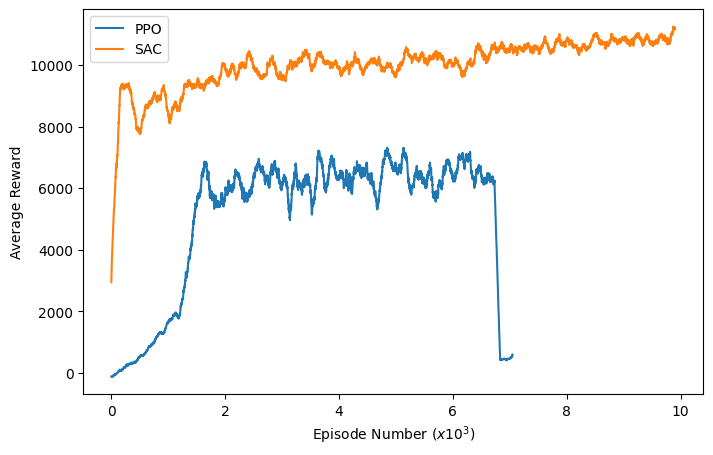

In [3]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def moving_average(data, window_size=5):
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

experiment_names = ['ppo_c10+n-10_b100', 'sac_c10+n-10_b100']  # Add other experiments if needed

plt.figure(figsize=(8, 5))  # Set figure size

for experiment in experiment_names:
    rewards = []
    experiment_numbers = []
    experiment_folder_path = os.path.join('experiments', experiment)
    training_data_path = os.path.join(experiment_folder_path, 'training_data.csv')

    df = pd.read_csv(training_data_path)
    index_value = df.index[df['timestep'] == 0].tolist()

    for i in range(len(index_value)):
        if i != len(index_value) - 1:
            start_index = index_value[i]
            end_index = index_value[i + 1] - 1

            subset_df = df.loc[start_index:end_index, ['reward', 'experiment_number']]
            reward_sum = subset_df['reward'].sum()
            rewards.append(reward_sum)
            experiment_number = subset_df['experiment_number'].iloc[0]
            experiment_numbers.append(experiment_number/1e3)
    if 'ppo' in experiment:
        display_name = "PPO"
    elif 'sac' in experiment:
        display_name = "SAC"
    # Apply moving average smoothing
    if len(rewards) > 100:  # Ensure enough points for smoothing
        smoothed_rewards = moving_average(rewards, window_size=100)
        smoothed_experiment_numbers = experiment_numbers[:len(smoothed_rewards)]
        plt.plot(smoothed_experiment_numbers, smoothed_rewards, label=display_name)
    else:
        plt.plot(experiment_numbers, rewards, label=experiment)

# Set global font to Times New Roman
plt.rcParams["font.family"] = "sans-serif"

plt.xlabel(r"Episode Number $(x10^3)$")
plt.ylabel("Average Reward")
plt.legend()  # Add legend for multiple experiments
# Save the figure
figure_path = os.path.join('figures', 'supplementary', 'figure6.svg')
plt.savefig(figure_path, format="svg", bbox_inches="tight", dpi=600)
plt.show()  # Display the plot


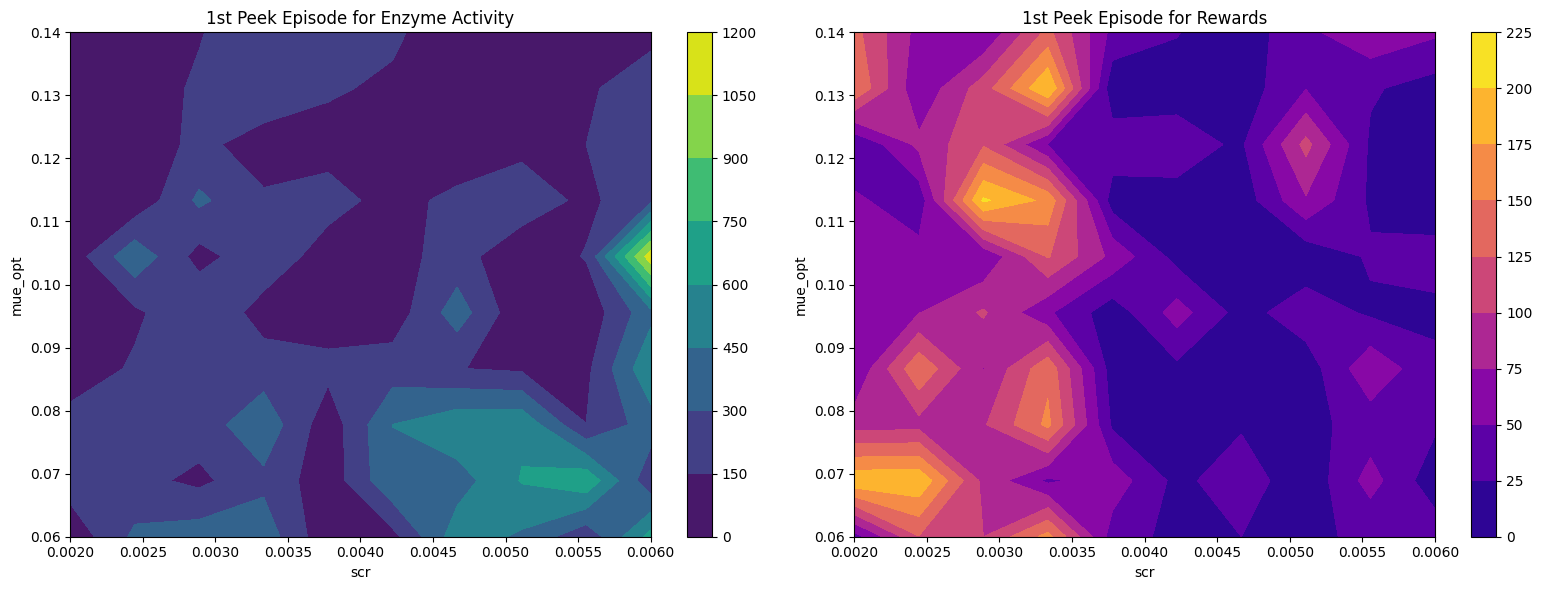

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

data = pd.read_csv('data_1.csv')

# Create meshgrid for contour plots
x = data['scr']
y = data['mue_opt']
X, Y = np.meshgrid(np.unique(x), np.unique(y))

# Interpolate Z values for contour plotting
Z1 = data.pivot(index='mue_opt', columns='scr', values='ea_peak_exp').values
Z2 = data.pivot(index='mue_opt', columns='scr', values='rew_peak_exp').values

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# First contour plot for ea_peak_exp
c1 = ax[0].contourf(X, Y, Z1, cmap='viridis')
fig.colorbar(c1, ax=ax[0])
ax[0].set_title('1st Peek Episode for Enzyme Activity')
ax[0].set_xlabel('scr')
ax[0].set_ylabel('mue_opt')

# Second contour plot for rew_peak_exp
c2 = ax[1].contourf(X, Y, Z2, cmap='plasma')
fig.colorbar(c2, ax=ax[1])
ax[1].set_title('1st Peek Episode for Rewards')
ax[1].set_xlabel('scr')
ax[1].set_ylabel('mue_opt')

plt.tight_layout()
plt.show()
